# Predicting wait time from Background neuron firing

In [7]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

Import dataset:

In [3]:
pickle_file_path = 'dataset_v0.pickle'
with open(pickle_file_path, 'rb') as file:
    dataset, labels = pickle.load(file)

/var/folders/dt/crdhdml12gz3wxrz_v86_ngw0000gp/T/ipykernel_39308/3214864628.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataset, labels = pickle.load(file)


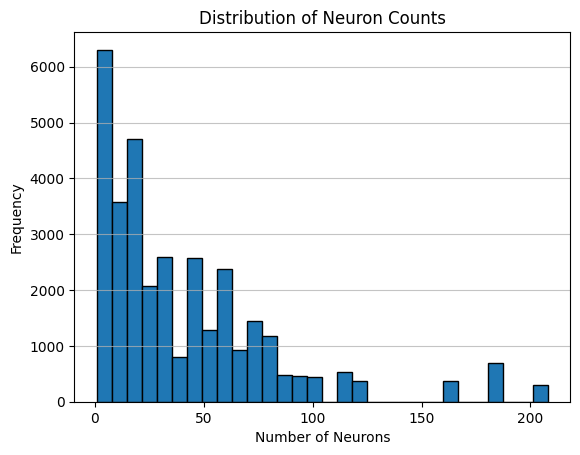

In [8]:
neuron_counts = [data.shape[0] for data in dataset]
plt.hist(neuron_counts, bins=30, edgecolor='black')
plt.title('Distribution of Neuron Counts')
plt.xlabel('Number of Neurons')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

In [157]:
clean_dataset = []
clean_labels = []
    
for data, label in zip(dataset, labels):
    if data.shape[0] > 30 and data.shape[0] < 125 and label<30:
        clean_dataset.append(data)
        clean_labels.append(label)

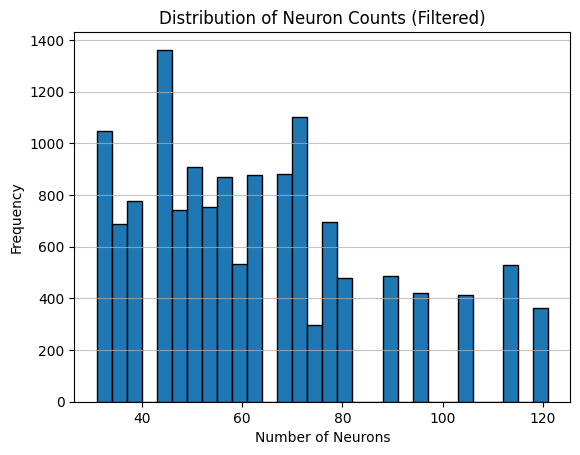

In [158]:
neuron_counts = [data.shape[0] for data in clean_dataset]
plt.hist(neuron_counts, bins=30, edgecolor='black')
plt.title('Distribution of Neuron Counts (Filtered)')
plt.xlabel('Number of Neurons')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

In [159]:
dataset = clean_dataset
labels = clean_labels

## Naive approach, Mean Pooling and simple models

In [160]:
# Find the maximum number of rows and columns across all arrays
max_neurons = max(data.shape[0] for data in dataset)

# Pad each array with zeros to match the maximum number of neurons
padded_dataset = [np.pad(data, ((0, max_neurons - data.shape[0]), (0, 0)), mode='constant') for data in dataset]

# Stack the padded arrays along a new axis
dataset_stacked = np.stack(padded_dataset, axis=0)
print(dataset_stacked.shape)


(14230, 121, 50)


In [161]:
dataset_max_firing_rate = np.max(dataset_stacked, axis=1)
dataset_mean_firing_rate = np.mean(dataset_stacked, axis=1)
# dataset_flattened = dataset_stacked.reshape(dataset_stacked.shape[0], -1)
full_dataset = np.transpose(dataset_stacked, axes=(0, 2, 1))
full_dataset.shape
labels = np.array(labels).reshape(-1, 1)

## First set of simple models

In [162]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [163]:

# Apply Min-Max Scaling
scaler = MinMaxScaler()
labels_normalized = scaler.fit_transform(labels)
full_dataset_normalized = scaler.fit_transform(full_dataset.reshape(-1, full_dataset.shape[-1])).reshape(full_dataset.shape)

X = full_dataset_normalized  # Features
y = labels  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [164]:
print("Basic Statistics for Labels:")
print(f"Mean: {np.mean(y):.2f}")
print(f"Median: {np.median(y):.2f}")
print(f"Standard Deviation: {np.std(y):.2f}")
print(f"Minimum: {np.min(y):.2f}")
print(f"Maximum: {np.max(y):.2f}")
print(f"Number of Samples: {len(y)}")

Basic Statistics for Labels:
Mean: 3.41
Median: 2.18
Standard Deviation: 3.92
Minimum: 0.01
Maximum: 29.89
Number of Samples: 14230


In [153]:
# Initialize models
models = {
    "Dummy Regressor": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Support Vector Regressor": SVR()
}

In [ ]:
# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name}:")
    print(f"  Mean Squared Error: {mse:.2f}")
    print(f"  R^2 Score: {r2:.2f}")
    print()

Dummy Regressor:
  Mean Squared Error: 0.02
  R^2 Score: -0.00

Linear Regression:
  Mean Squared Error: 0.02
  R^2 Score: -0.00



/Users/ferran/miniconda3/envs/cheerios/lib/python3.9/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest:
  Mean Squared Error: 0.02
  R^2 Score: -0.07



/Users/ferran/miniconda3/envs/cheerios/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Support Vector Regressor:
  Mean Squared Error: 0.02
  R^2 Score: -0.06



In [165]:
# Build the RNN model
model = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    Dense(32, activation='relu'),
    Dense(1)  
])

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

# Calculate R² score manually
r2 = r2_score(y_test, y_pred)
print(f"Test Loss: {loss:.4f}, Test MAE: {mae:.4f}, Test R²: {r2:.4f}")

Epoch 1/10


/Users/ferran/miniconda3/envs/cheerios/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 26.3684 - mae: 3.3088 - val_loss: 16.2948 - val_mae: 2.5332
Epoch 2/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 16.1002 - mae: 2.5350 - val_loss: 15.3576 - val_mae: 2.5079
Epoch 3/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 16.2283 - mae: 2.5869 - val_loss: 15.4089 - val_mae: 2.3980
Epoch 4/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 16.0457 - mae: 2.5299 - val_loss: 14.8228 - val_mae: 2.5216
Epoch 5/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 14.5266 - mae: 2.4591 - val_loss: 14.7136 - val_mae: 2.4766
Epoch 6/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 14.9072 - mae: 2.4459 - val_loss: 14.5928 - val_mae: 2.5511
Epoch 7/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 14.3298 - mae: 2.4412 - val_loss: 14.5319 - val_mae: 2.4695
Epoch 8/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 15.0766 - mae: 2.5002 - val_loss: 14.4952 - val_mae: 2.4606
Epoch 9/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

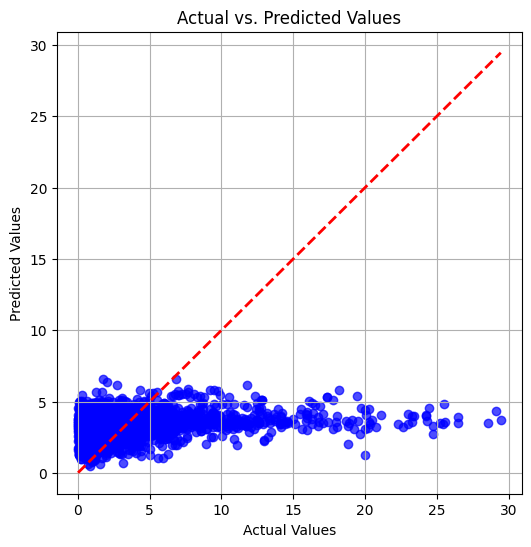

In [166]:
# Assuming y_test (actual values) and y_pred (predicted values) are available
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid()
plt.show()

In [105]:
y_pred.max()

np.float32(0.07941262)